# Micrograd: 深入理解神经网络反向传播 (From Andrej Karpathy)

在这个 Notebook 中，我们将从零开始构建 `micrograd`。这是一个极简的自动微分（Autograd）引擎。虽然它的代码量很小，但它实现了现代深度学习库（如 PyTorch）的核心机制：**反向传播（Backpropagation）**。

正如 Karpathy 所说，理解了 `micrograd`，你就理解了神经网络训练的"幕后"机制。

## 第一部分：微积分直觉与导数

在构建神经网络之前，我们需要理解"导数"实际上在测量什么。导数衡量的是：如果我们稍微改变输入（$h$），输出会如何变化？

数学定义：
$$ \frac{df(x)}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h} $$

我们用代码来直观感受这个概念。

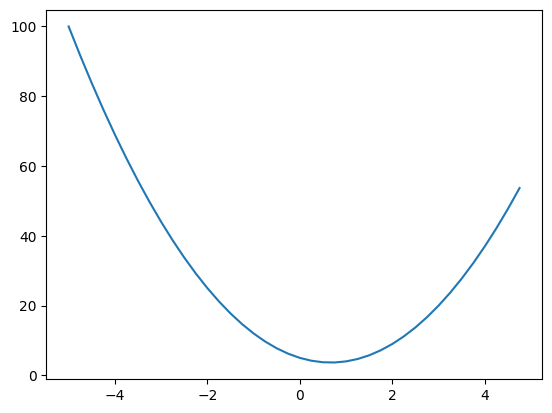

In [1]:
# Cell 1: 可视化函数
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def f(x):
    return 3*x**2 - 4*x + 5

# 让我们看看这个函数的形状
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)
plt.show()

### 数值近似导数

我们可以通过选取一个极小的 $h$ 来数值近似导数。这告诉我们函数在某一点的"斜率"或"敏感度"。

In [2]:
# Cell 2: 数值近似导数
h = 0.000001
x = 3.0
# 函数在 x 点的值
val = f(x) 
# 函数在 x+h 点的值（稍微增加 x）
val_bump = f(x + h)

# 斜率 = (y的变化) / (x的变化)
slope = (val_bump - val) / h
print(f"在 x={x} 处的数值斜率: {slope}")
# 解析解：f'(x) = 6x - 4 -> f'(3) = 18 - 4 = 14. 结果应该非常接近 14。

在 x=3.0 处的数值斜率: 14.000003002223593


### 梯度下降的直觉：使用导数来优化

既然我们已经知道如何计算导数，那么导数有什么用呢？在神经网络训练中，我们使用导数来**最小化损失函数（Loss Function）**。

#### 核心思想

导数的符号告诉我们函数在某一点是**上升**还是**下降**：
- 如果导数 $f'(x) > 0$：函数在上升，要减小函数值，我们应该**向左**移动（减小 $x$）
- 如果导数 $f'(x) < 0$：函数在下降，要减小函数值，我们应该**向右**移动（增大 $x$）

换句话说，**梯度（导数）指向函数值增加的方向**。要最小化函数，我们需要向梯度的**反方向**移动。

#### 梯度下降公式

$$ x_{new} = x_{old} - \alpha \times f'(x_{old}) $$

其中：
- $\alpha$ 是**学习率（Learning Rate）**，控制我们每次移动的步长
- 负号表示我们向梯度反方向移动（下山）

让我们用代码来演示这个过程：

In [ ]:
# Cell 3: 梯度下降演示
# 使用梯度下降找到函数的最小值

# 函数的解析导数
def df(x):
    return 6*x - 4  # f'(x) = 6x - 4

# 初始值（从函数值较大的点开始）
x = 5.0
learning_rate = 0.1  # 学习率：控制步长
iterations = 20

print(f"初始值: x = {x:.4f}, f(x) = {f(x):.4f}")
print(f"学习率: {learning_rate}")
print("\n开始梯度下降迭代：")
print("-" * 50)

for i in range(iterations):
    # 计算当前点的导数（梯度）
    grad = df(x)
    
    # 梯度下降更新：向梯度反方向移动
    x = x - learning_rate * grad
    
    # 打印当前状态
    print(f"步骤 {i+1:2d}: x = {x:.4f}, f(x) = {f(x):.4f}, f'(x) = {grad:.4f}")

print("-" * 50)
print(f"\n最终结果: x = {x:.4f}, f(x) = {f(x):.4f}")
print(f"理论最小值: x = {4/6:.4f}, f(x) = {f(4/6):.4f}")
print("\n注意：梯度下降帮助我们找到了函数的最小值点！")

#### 关键观察

1. **学习率的重要性**：
   - **太小**（如 0.001）：收敛很慢，需要很多步才能接近最小值
   - **太大**（如 1.0）：可能会"跳过"最小值，导致震荡甚至发散
   - **合适**（如 0.1）：能够稳定地收敛到最小值

2. **梯度告诉我们方向**：
   - 当 $f'(x) > 0$ 时，我们减小 $x$（向左移动）
   - 当 $f'(x) < 0$ 时，我们增大 $x$（向右移动）
   - 当 $f'(x) = 0$ 时，我们到达了极值点（可能是最小值或最大值）

3. **在神经网络中的应用**：
   - 损失函数 $L$ 是我们想要最小化的函数
   - 参数（权重 $w$ 和偏置 $b$）是我们想要优化的变量
   - 梯度 $\frac{\partial L}{\partial w}$ 告诉我们如何调整权重来减小损失
   - 更新公式：$w_{new} = w_{old} - \alpha \times \frac{\partial L}{\partial w}$

这就是神经网络训练的**核心机制**：通过计算损失函数对每个参数的梯度，然后沿着梯度反方向更新参数，逐步减小损失。

## 第二部分：构建核心引擎 `Value` 类

这是 Micrograd 的心脏。我们将把普通的数字包装在一个 `Value` 对象中。这个对象不仅存储数据，还存储了产生这个数据的**操作历史**（它是由谁相加或相乘得到的）。这构成了**计算图（Computational Graph）**。

### 关键设计点（依据视频讲解）：

1. **`grad` (梯度)**: 存储输出关于该值的导数。初始为0，意味着该值对输出没有影响。
2. **`_backward`**: 这是一个函数闭包。它存储了如何计算该节点的**局部梯度**，并将其通过**链式法则（Chain Rule）**传播给子节点。
3. **`backward()`**: 这是一个全自动的方法。它首先对图进行**拓扑排序（Topological Sort）**，确保我们从输出节点反向依次计算梯度。
4. **梯度累积 (`+=`)**: 这是一个常见的 Bug 修复点。如果一个变量被多次使用（例如 `b = a + a`），梯度应该累加，而不是覆盖。

In [3]:
# Cell 3: Value 类 - Micrograd 的核心引擎
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0      # 梯度：损失函数相对于该值的导数
        self._backward = lambda: None # 默认不做任何事（叶子节点）
        self._prev = set(_children)   # 存储前驱节点，用于构建图
        self._op = _op       # 产生该值的操作符 (用于调试/可视化)
        self.label = label   # 变量名 (用于调试)

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        # 支持常数相加 (如 x + 1)
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            # 加法的局部导数是 1.0。
            # 链式法则：将上游梯度 (out.grad) 传递给输入。
            # 注意使用 += 进行累积，处理变量复用的情况。
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            # 乘法链式法则：f(x,y) = xy -> df/dx = y
            # 梯度 = 局部导数 * 上游梯度
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        # 处理 x**k，其中 k 是常数
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            # 幂规则：n * x^(n-1)
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other): # 支持 2 * a
        return self * other

    def __truediv__(self, other): # 支持 a / b
        return self * other**-1

    def __neg__(self): # 支持 -a
        return self * -1

    def __sub__(self, other): # 支持 a - b
        return self + (-other)
    
    def __radd__(self, other): # 支持 1 + a
        return self + other

    def tanh(self):
        # tanh 激活函数
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            # tanh 的导数是 (1 - tanh^2)
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        # 指数函数，用于实现 tanh 或其他操作
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            # e^x 的导数就是 e^x
            self.grad += out.data * out.grad 
        out._backward = _backward
        return out

    def backward(self):
        # 拓扑排序：确保我们在处理节点之前，已经处理了所有依赖它的节点
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # 设置根节点（通常是 Loss）的梯度为 1.0
        self.grad = 1.0
        #以此反向顺序应用链式法则
        for node in reversed(topo):
            node._backward()

## 第三部分：可视化计算图

为了直观地看到我们构建了什么，我们需要用到 `graphviz`。这将帮助我们画出每个 `Value` 对象及其连接关系。这对于调试非常有帮助。

*(注：运行此单元格需要你的环境中安装了 graphviz)*

In [4]:
# Cell 4: 可视化计算图
from graphviz import Digraph

def trace(root):
    # 收集图中所有的点和边
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # 从左到右布局
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # 数据节点（矩形）- 显示 label、data 和 grad
        # 构建标签字符串
        label_parts = []
        if n.label:
            label_parts.append(f"label: {n.label}")
        label_parts.append(f"data: {n.data:.4f}")
        label_parts.append(f"grad: {n.grad:.4f}")
        label_str = "|".join(label_parts)
        dot.node(name=uid, label=f"{{ {label_str} }}", shape='record')
        
        # 操作符节点（圆形）
        if n._op:
            # 为操作符创建一个小节点
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)  # 操作符 -> 数据节点
    
    # 连接节点之间的边（数据流向）
    for n1, n2 in edges:
        # 连接节点：从子节点指向父节点的操作符
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

### 测试 Value 类：数值微分验证

在实现自动微分之前，让我们先用**数值微分**的方法来验证我们的计算是否正确。

#### 什么是数值微分？

数值微分通过微小的扰动来近似计算导数：
$$ f'(x) \approx \frac{f(x + h) - f(x)}{h} $$

其中 $h$ 是一个非常小的数（如 0.0001）。

#### 示例：计算 $e = (a + b)^2$ 对 $a$ 的导数

我们的计算：
- $c = a + b$，其中 $a = 1$, $b = 2$，所以 $c = 3$
- $e = c \times c = c^2 = 9$

理论导数：
- $e = (a + b)^2$
- $\frac{\partial e}{\partial a} = 2(a + b) = 2(1 + 2) = 6$

数值微分验证：
- 将 $a$ 增加 $h = 0.0001$
- 重新计算 $e$，得到 $H2$
- 计算 $(H2 - H1) / h$，应该接近 $6$

运行下面的单元格，看看数值微分的结果是否接近理论值 $6$。

In [ ]:
# 数值微分验证
def numerical_gradient_check():
    h = 0.0001
    
    # 第一次计算
    a = Value(1, label='a')
    b = Value(2, label='b')
    c = a + b
    c.label = 'c'
    e = c * c
    e.label = 'e'
    H1 = e.data

    # 第二次计算（a 增加 h）
    a = Value(1 + h, label='a')
    b = Value(2, label='b')
    c = a + b
    c.label = 'c'
    e = c * c
    e.label = 'e'
    H2 = e.data

    # 数值梯度
    numerical_grad = (H2 - H1) / h
    
    print(f"数值梯度: {numerical_grad:.6f}")
    print(f"理论梯度: 6.0")
    print(f"误差: {abs(numerical_grad - 6.0):.6f}")
    
    return numerical_grad

numerical_gradient_check()

### 深入理解 `_prev` 集合的行为

**重要发现**：当两个操作数是同一个对象时，集合会自动去重！

#### 示例分析：

```python
e = c * c  # 两个操作数都是 c
e._prev   # 输出：{data=3, label=c}
```

**为什么只有一个元素？**

- `e._prev` 是 `set({c, c})`
- Python 的 `set()` 会自动去除重复元素
- 所以 `{c, c}` 变成了 `{c}`
- 这就是为什么输出只显示一个 `c` 对象

#### 验证方法：

你可以通过以下方式验证：

```python
print(f"e._prev 的长度: {len(e._prev)}")  # 输出: 1
print(f"e._prev 的内容: {e._prev}")        # 输出: {data=3, label=c}
```

#### 思考题：

- 如果 `e = a * b`（两个不同的对象），`e._prev` 会包含几个元素？
- 集合去重对计算图有什么影响？
- 为什么使用 `set()` 而不是 `list()` 来存储 `_prev`？

In [ ]:
# 验证 _prev 集合的去重行为
a = Value(1, label='a')
b = Value(2, label='b')
c = a + b
c.label = 'c'
e = c * c  # 两个操作数都是 c
e.label = 'e'

print(f"e._prev 的长度: {len(e._prev)}")
print(f"e._prev 的内容: {e._prev}")
print(f"\n注意：虽然 c * c 有两个操作数，但 _prev 集合只包含一个 c 对象（自动去重）")

## 第三部分补充：链式法则的复杂示例

让我们创建一个复杂的计算图来深入理解链式法则的工作原理：$f = (a + b) \times (c - d) + e^2$

### 计算图结构：

```
a ──┐
    ├─→ (a+b) ──┐
b ──┘           │
                ├─→ (a+b)*(c-d) ──┐
c ──┐           │                 │
    ├─→ (c-d) ──┘                 ├─→ f = (a+b)*(c-d) + e²
d ──┘                            │
                                 │
e ──→ e² ────────────────────────┘
```

### 手动计算梯度（验证用）：

假设 $a=2, b=3, c=5, d=1, e=4$，则：
- $f = (2+3) \times (5-1) + 4^2 = 5 \times 4 + 16 = 36$

梯度计算：
- $\frac{\partial f}{\partial a} = (c-d) = 4$
- $\frac{\partial f}{\partial b} = (c-d) = 4$
- $\frac{\partial f}{\partial c} = (a+b) = 5$
- $\frac{\partial f}{\partial d} = -(a+b) = -5$
- $\frac{\partial f}{\partial e} = 2e = 8$

运行下面的单元格，看看自动微分的结果是否与手动计算一致。

In [ ]:
# 复杂示例：f = (a + b) * (c - d) + e^2
a = Value(2.0, label='a')
b = Value(3.0, label='b')
c = Value(5.0, label='c')
d = Value(1.0, label='d')
e = Value(4.0, label='e')

# 构建计算图
ab_sum = a + b
ab_sum.label = 'a+b'

cd_diff = c - d
cd_diff.label = 'c-d'

product = ab_sum * cd_diff
product.label = '(a+b)*(c-d)'

e_squared = e ** 2
e_squared.label = 'e²'

f = product + e_squared
f.label = 'f'

print(f"前向传播结果: f = {f.data}")
print(f"预期结果: f = (2+3)*(5-1) + 4² = 5*4 + 16 = 36")
print()

# 反向传播
f.backward()

# 显示所有节点的梯度
print("=" * 60)
print("梯度计算结果（使用链式法则）:")
print("=" * 60)
print(f"∂f/∂a = {a.grad:.4f} (预期: 4.0)")
print(f"∂f/∂b = {b.grad:.4f} (预期: 4.0)")
print(f"∂f/∂c = {c.grad:.4f} (预期: 5.0)")
print(f"∂f/∂d = {d.grad:.4f} (预期: -5.0)")
print(f"∂f/∂e = {e.grad:.4f} (预期: 8.0)")
print()

# 显示中间节点的梯度
print("中间节点的梯度:")
print(f"∂f/∂(a+b) = {ab_sum.grad:.4f}")
print(f"∂f/∂(c-d) = {cd_diff.grad:.4f}")
print(f"∂f/∂((a+b)*(c-d)) = {product.grad:.4f}")
print(f"∂f/∂(e²) = {e_squared.grad:.4f}")
print()

# 可视化计算图（包含梯度）
print("计算图可视化（包含梯度）:")
draw_dot(f)

### 理解链式法则的工作原理

让我们详细分析梯度是如何通过链式法则传播的：

#### 梯度传播路径：

1. **初始化**：`f.grad = 1.0`（输出节点）

2. **从 f 到 product 和 e_squared**：
   - $f = \text{product} + \text{e\_squared}$
   - 局部梯度：$\frac{\partial f}{\partial \text{product}} = 1$, $\frac{\partial f}{\partial \text{e\_squared}} = 1$
   - 全局梯度：`product.grad = 1.0 × 1 = 1.0`
   - 全局梯度：`e_squared.grad = 1.0 × 1 = 1.0`

3. **从 product 到 ab_sum 和 cd_diff**：
   - $\text{product} = \text{ab\_sum} \times \text{cd\_diff}$
   - 局部梯度：$\frac{\partial \text{product}}{\partial \text{ab\_sum}} = \text{cd\_diff}.data = 4$
   - 局部梯度：$\frac{\partial \text{product}}{\partial \text{cd\_diff}} = \text{ab\_sum}.data = 5$
   - 全局梯度：`ab_sum.grad = product.grad × cd_diff.data = 1.0 × 4 = 4.0`
   - 全局梯度：`cd_diff.grad = product.grad × ab_sum.data = 1.0 × 5 = 5.0`

4. **从 ab_sum 到 a 和 b**：
   - $\text{ab\_sum} = a + b$
   - 局部梯度：$\frac{\partial \text{ab\_sum}}{\partial a} = 1$, $\frac{\partial \text{ab\_sum}}{\partial b} = 1$
   - 全局梯度：`a.grad = ab_sum.grad × 1 = 4.0 × 1 = 4.0`
   - 全局梯度：`b.grad = ab_sum.grad × 1 = 4.0 × 1 = 4.0`

5. **从 cd_diff 到 c 和 d**：
   - $\text{cd\_diff} = c - d$
   - 局部梯度：$\frac{\partial \text{cd\_diff}}{\partial c} = 1$, $\frac{\partial \text{cd\_diff}}{\partial d} = -1$
   - 全局梯度：`c.grad = cd_diff.grad × 1 = 5.0 × 1 = 5.0`
   - 全局梯度：`d.grad = cd_diff.grad × (-1) = 5.0 × (-1) = -5.0`

6. **从 e_squared 到 e**：
   - $\text{e\_squared} = e^2$
   - 局部梯度：$\frac{\partial \text{e\_squared}}{\partial e} = 2 \times e = 2 \times 4 = 8$
   - 全局梯度：`e.grad = e_squared.grad × 8 = 1.0 × 8 = 8.0`

#### 关键洞察：

- **局部梯度**是每个操作对其输入的导数
- **全局梯度**通过链式法则累积：$\text{全局梯度} = \text{上游梯度} \times \text{局部梯度}$
- 使用 `+=` 是因为一个节点可能被多个路径使用（如 `c * c`）

运行下面的单元格，查看详细的梯度传播过程。

### 详细展示梯度传播过程

下面的函数可以帮助我们理解梯度是如何通过链式法则传播的：

In [ ]:
# 详细展示梯度传播过程
def print_gradient_flow(root):
    """打印梯度传播的详细信息"""
    nodes, edges = trace(root)
    
    # 按拓扑顺序排序（从叶子到根）
    topo = []
    visited = set()
    
    def build_topo(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)
    
    build_topo(root)
    
    print("梯度传播顺序（从输出到输入）:")
    print("=" * 70)
    
    for i, node in enumerate(reversed(topo)):
        label = node.label if node.label else f"node_{id(node)}"
        print(f"\n步骤 {i+1}: {label}")
        print(f"  数据值: {node.data:.4f}")
        print(f"  梯度值: {node.grad:.4f}")
        if node._op:
            print(f"  操作: {node._op}")
            print(f"  父节点: {[c.label if c.label else f'node_{id(c)}' for c in node._prev]}")

# 重新运行示例
a = Value(2.0, label='a')
b = Value(3.0, label='b')
c = Value(5.0, label='c')
d = Value(1.0, label='d')
e = Value(4.0, label='e')

ab_sum = a + b; ab_sum.label = 'a+b'
cd_diff = c - d; cd_diff.label = 'c-d'
product = ab_sum * cd_diff; product.label = '(a+b)*(c-d)'
e_squared = e ** 2; e_squared.label = 'e²'
f = product + e_squared; f.label = 'f'

f.backward()
print_gradient_flow(f)

## 第四部分：构建神经网络 (PyTorch 风格)

现在有了引擎，我们可以构建神经元了。神经网络本质上就是一堆数学表达式。

*   **Neuron (神经元)**: 计算 $w \cdot x + b$，然后通过非线性激活函数 (如 tanh)。
*   **Layer (层)**: 一组独立的神经元。
*   **MLP (多层感知机)**: 串联的层。

这部分代码模仿了 PyTorch 的 `nn.Module` API。

In [5]:
# Cell 5: 构建神经网络
import random

class Neuron:
    def __init__(self, nin):
        # nin: 输入的数量
        # 初始化权重 w (随机) 和偏置 b (随机)
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # 计算：w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        # 应用非线性激活函数 tanh
        out = act.tanh()
        return out

    def parameters(self):
        # 返回该神经元的所有参数，用于后续更新
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        # 创建 nout 个独立的神经元
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        # nin: 输入维度
        # nouts: 一个列表，定义每一层的神经元数量
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        # 顺序通过所有层
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

## 第五部分：训练循环 (The Training Loop)

这是最神奇的部分。我们将定义一个简单的数据集，并训练 MLP 来拟合它。

### 训练过程的核心步骤

训练过程分为五个关键步骤（Karpathy 在视频中反复强调的流程）：

1.  **Forward Pass (前向传播)**: 计算当前网络对所有样本的预测值。
2.  **Calculate Loss (计算损失)**: 衡量预测有多差（这里使用均方误差 MSE）。
3.  **Zero Grad (梯度归零)**: **这是深度学习中最常见的 Bug 之一！** 在反向传播前，必须将所有参数的梯度重置为 0。如果不这样做，新的梯度会累加到旧梯度上，导致步长越来越大，Loss 可能爆炸。
4.  **Backward Pass (反向传播)**: 计算损失相对于所有参数（权重 $w$ 和偏置 $b$）的梯度。
5.  **Update (参数更新)**: 根据梯度反向微调参数，使用梯度下降公式：$w_{new} = w_{old} - \alpha \times \frac{\partial L}{\partial w}$

### 为什么需要梯度清零？

在 `backward()` 方法中，我们使用 `+=` 来累积梯度（这是为了处理一个变量被多次使用的情况，如 `c = a + a`）。

**如果不手动清零会发生什么？**
- 第一轮的梯度会遗留在 `p.grad` 中
- 第二轮计算出的梯度会**加上**第一轮的梯度
- 随着迭代进行，梯度值会变得巨大
- 参数更新会过度，Loss 不降反升，甚至变成 `inf`（无穷大）

**正确的做法**：在每次反向传播之前，必须执行 `p.grad = 0.0` 来清零所有参数的梯度。

### 学习率的选择

学习率 $\alpha$ 控制我们沿着梯度反方向移动的步长：
- **太小**（如 0.001）：Loss 下降非常慢，仿佛是在用勺子挖山
- **太大**（如 1.0）：Loss 可能会变得很不稳定，甚至突然变成 `inf`。这是因为步子太大，"跳过"了谷底，跳到了对面更高的山上
- **合适**（如 0.05）：能够稳定地收敛，Loss 逐步减小

通过这个循环，我们完成了神经网络训练的闭环：**Forward → Loss → ZeroGrad → Backward → Update**。

In [6]:
# Cell 6: 训练循环
# 1. 定义数据集
# 输入数据 (4个样本，每个样本3个特征)
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
# 目标输出 (期望的分类标签)
ys = [1.0, -1.0, -1.0, 1.0]

# 2. 初始化神经网络
# 3个输入 -> 隐藏层1(4个神经元) -> 隐藏层2(4个神经元) -> 输出层(1个神经元)
n = MLP(3, [4, 4, 1])

# 3. 训练循环
epochs = 20
learning_rate = 0.05  # 学习率：控制参数更新的步长

print(f"开始训练... 学习率: {learning_rate}, 迭代次数: {epochs}")
print("=" * 60)

for k in range(epochs):
    
    # --- 步骤 1: Forward Pass (前向传播) ---
    # 计算当前网络对所有样本的预测
    ypred = [n(x) for x in xs]
    
    # --- 步骤 2: Calculate Loss (计算损失) ---
    # 计算均方误差 (Mean Squared Error Loss)
    # Loss = sum((y_pred - y_true)^2)
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    
    # --- 步骤 3: Zero Grad (梯度清零) - 关键步骤！---
    # 在反向传播之前，必须将所有参数的梯度重置为 0。
    # 如果不这样做，新的梯度会累加到旧梯度上，导致步长越来越大，Loss 爆炸。
    # 这是深度学习中最常见的 Bug 之一！
    for p in n.parameters():
        p.grad = 0.0
    
    # --- 步骤 4: Backward Pass (反向传播) ---
    # 计算 Loss 对所有参数 (w, b) 的导数
    # 这会自动填充每个参数的 .grad 属性
    loss.backward()
    
    # --- 步骤 5: Update (参数更新 / 梯度下降) ---
    # 遍历整个网络的所有参数，利用梯度下降公式进行微调
    # 公式：data = data - learning_rate * gradient
    # 负号意味着我们走向梯度的反方向（下山，减小 Loss）
    for p in n.parameters():
        p.data += -learning_rate * p.grad
        
    # 打印当前进度
    print(f"Step {k:2d} | Loss: {loss.data:.4f}")

print("\n最终预测值:", [val.data for val in ypred])
print("目标值:", ys)

Step 0 | Loss: 5.7644
Step 1 | Loss: 3.3988
Step 2 | Loss: 1.8478
Step 3 | Loss: 1.0331
Step 4 | Loss: 0.6088
Step 5 | Loss: 0.3974
Step 6 | Loss: 0.2776
Step 7 | Loss: 0.2034
Step 8 | Loss: 0.1555
Step 9 | Loss: 0.1237
Step 10 | Loss: 0.1017
Step 11 | Loss: 0.0859
Step 12 | Loss: 0.0742
Step 13 | Loss: 0.0651
Step 14 | Loss: 0.0580
Step 15 | Loss: 0.0522
Step 16 | Loss: 0.0474
Step 17 | Loss: 0.0435
Step 18 | Loss: 0.0401
Step 19 | Loss: 0.0372

最终预测值: [0.924907327990185, -0.8780366013962555, -0.9111134753842022, 0.9065140718728353]
目标值: [1.0, -1.0, -1.0, 1.0]


### 可视化最终的计算图 (可选)

这会生成一张巨大的图，展示了四个样本的前向传播和损失计算过程。

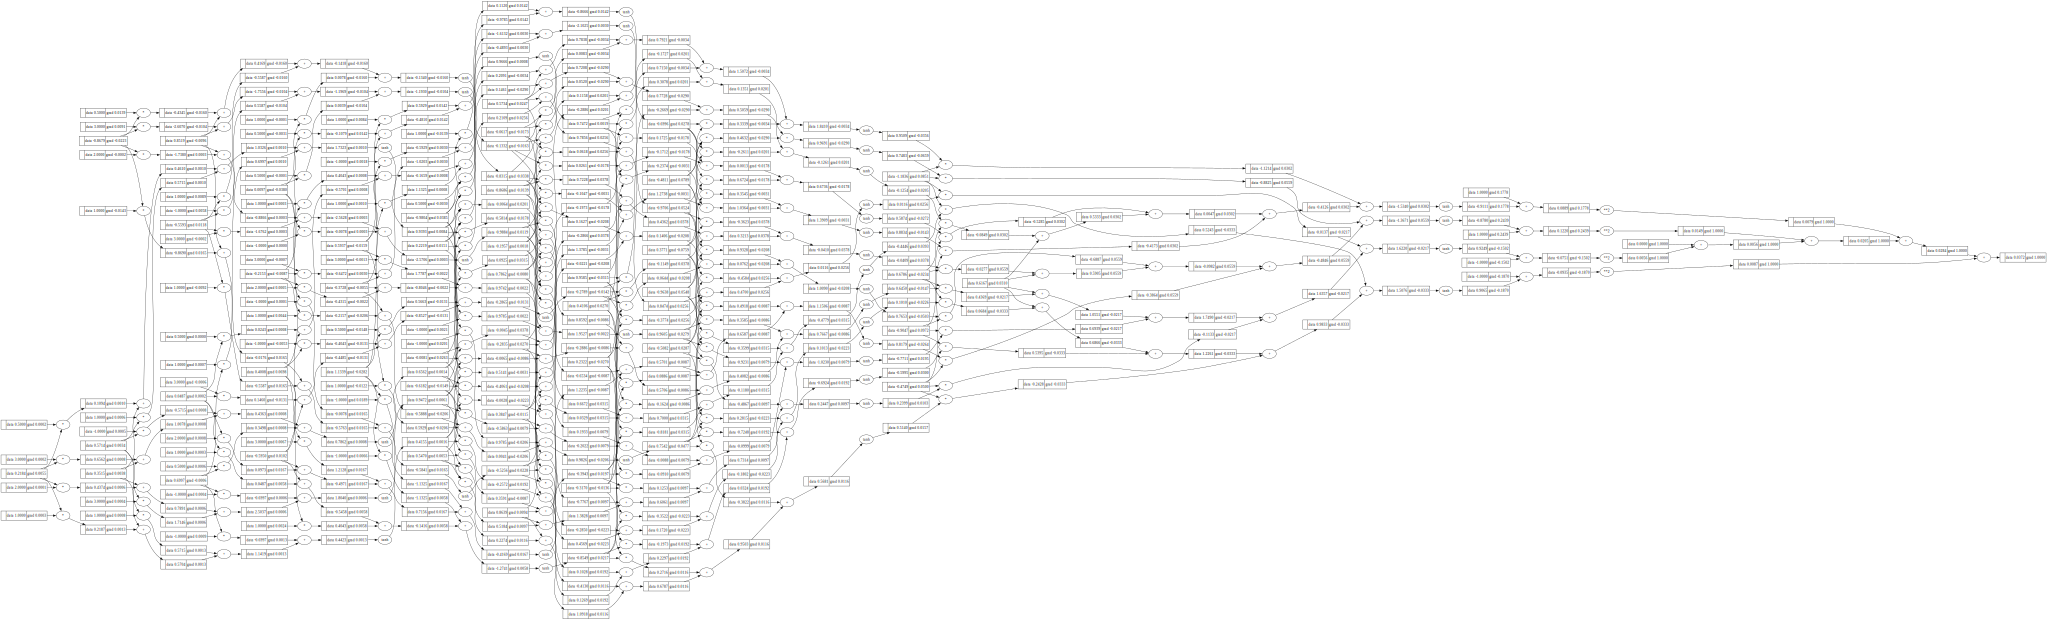

In [7]:
# Cell 7: 可视化计算图（可选，图可能会很大）
# 注意：这一步生成的图可能会很大，包含所有4个样本的计算过程
# 如果图太大，可以注释掉这一行
draw_dot(loss)